In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

2025-12-23 14:09:30.420081: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [23]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [4]:
X_train.shape

(60000, 28, 28)

In [5]:
y_train.shape

(60000,)

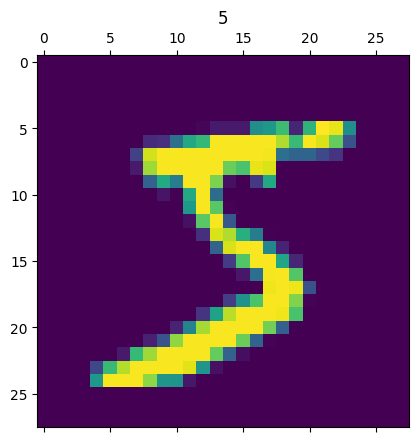

In [17]:
plt.matshow(X_train[0])
plt.title(y_train[0])
plt.show()

In [51]:
from tensorflow.keras import layers
model = keras.Sequential()
model.add(keras.Input(shape=(28,28, 1)))
model.add(layers.Conv2D(32, (3,3), activation= "relu"))
model.add(layers.MaxPool2D(3,3))
model.add(layers.Conv2D(64, (3,3), activation= "relu"))
model.add(layers.MaxPool2D(3,3))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation = "relu"))
model.add(layers.Dense(10, activation = "sigmoid"))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [52]:
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9144 - loss: 0.4732
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9697 - loss: 0.0877
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9729 - loss: 0.0676
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9703 - loss: 0.0570
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9706 - loss: 0.0492


In [53]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9696 - loss: 0.0624


[0.06236431747674942, 0.9696000218391418]

In [54]:
y_test_predicted = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [40]:
y_test_predicted[:5]

array([[9.9612862e-02, 6.0920519e-01, 9.9719238e-01, 6.0408616e-01,
        2.9933298e-02, 3.5363224e-01, 5.8400019e-07, 1.0000000e+00,
        9.1764206e-01, 9.9821985e-01],
       [9.9999934e-01, 6.4971197e-01, 1.0000000e+00, 3.6870036e-01,
        5.3156200e-06, 6.4229018e-05, 8.2530445e-01, 1.1639388e-02,
        9.8924685e-01, 1.2143890e-06],
       [9.9925786e-01, 1.0000000e+00, 9.9945372e-01, 2.9943556e-06,
        7.9565752e-01, 3.4288791e-01, 1.7667718e-01, 9.5029098e-01,
        9.9676317e-01, 2.0434797e-02],
       [1.0000000e+00, 1.2044560e-06, 9.9957395e-01, 9.6660405e-01,
        9.8926741e-01, 9.9872321e-01, 9.9996048e-01, 9.9636424e-01,
        9.8587286e-01, 9.9999946e-01],
       [1.6342148e-05, 2.0063519e-02, 1.9294697e-04, 4.5564423e-08,
        1.0000000e+00, 9.6615439e-04, 7.1752211e-03, 8.0515202e-03,
        8.0045336e-01, 9.9998903e-01]], dtype=float32)

In [55]:
y_test_predicted = [np.argmax(predicted) for predicted in y_test_predicted]

Text(95.72222222222221, 0.5, 'Truth')

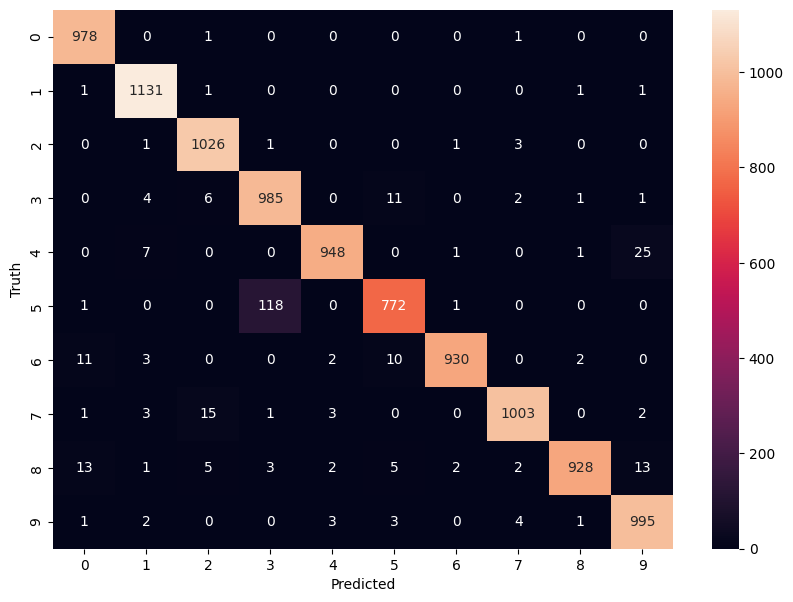

In [56]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_test_predicted)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.74      0.99      0.85       980
           1       0.97      0.99      0.98      1135
           2       0.95      0.96      0.96      1032
           3       0.99      0.97      0.98      1010
           4       0.74      0.99      0.84       982
           5       0.89      0.99      0.93       892
           6       0.99      0.55      0.71       958
           7       0.99      0.95      0.97      1028
           8       0.99      0.96      0.97       974
           9       0.97      0.66      0.78      1009

    accuracy                           0.90     10000
   macro avg       0.92      0.90      0.90     10000
weighted avg       0.92      0.90      0.90     10000



In [57]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 6, 6, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,744 (420.88 KB)

 Trainable params: 35,914 (140.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 71,830 (280.59 KB)